# **Echocardiogram / ECG Classification — CNN vs. Hybrid CNN-Transformer**

Dataset: [Echocardiogram(EKG) dataset](https://www.kaggle.com/datasets/kriegmann/echocardiogramekg-dataset)
— 4 cardiac condition classes: **Angina Disease, Cardio Vascular Disease, Coronary Artery
Disease, Hypotension Disease**, graded by cardiologists at the Marian Cardiac Centre, Poland.

## Setup & Data Acquisition

### Download dataset from Kaggle

In [1]:
from google.colab import files
files.upload()  # upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [3]:
!kaggle datasets download -d kriegmann/echocardiogramekg-dataset
!unzip -q -o echocardiogramekg-dataset.zip -d echo_ekg_data

Dataset URL: https://www.kaggle.com/datasets/kriegmann/echocardiogramekg-dataset
License(s): unknown
100% 74.1M/74.1M [00:00<00:00, 140MB/s]



### Imports

In [4]:
import os
import math
import random
import shutil
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Configuration

In [5]:
RAW_ROOT   = "echo_ekg_data"   # raw extracted zip contents
SPLIT_ROOT = "dataset"         # our own train/val/test folder structure goes here

image_size = (224, 224)
batch_size = 32
epochs     = 25

## **Data Discovery, Flattening & Train/Val/Test Split**

### Flatten the nested folders

In [6]:
top_level_dirs = [d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))]
print(f"Initial top-level directories in {RAW_ROOT}:\n{top_level_dirs}\n")

for disease_root_folder in top_level_dirs:
    full_disease_root_path = os.path.join(RAW_ROOT, disease_root_folder)

    sub_items = os.listdir(full_disease_root_path)
    sub_dirs = [item for item in sub_items if os.path.isdir(os.path.join(full_disease_root_path, item))]

    # Exactly one nested sub-folder -> move its contents up, then remove it
    if len(sub_dirs) == 1:
        nested_sub_folder_path = os.path.join(full_disease_root_path, sub_dirs[0])
        print(f"Flattening: {nested_sub_folder_path}")
        for item in os.listdir(nested_sub_folder_path):
            shutil.move(
                os.path.join(nested_sub_folder_path, item),
                os.path.join(full_disease_root_path, item)
            )
        os.rmdir(nested_sub_folder_path)

# Strip trailing underscores from folder names
top_level_dirs = [d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))]
for folder_name in top_level_dirs:
    if folder_name.endswith('_'):
        old_path = os.path.join(RAW_ROOT, folder_name)
        new_path = os.path.join(RAW_ROOT, folder_name.rstrip('_'))
        shutil.move(old_path, new_path)
        print(f"Renamed '{folder_name}' -> '{folder_name.rstrip(chr(39))}'")

class_names = sorted([d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))])
num_classes = len(class_names)
print(f"\nFinal classes ({num_classes}): {class_names}")

Initial top-level directories in echo_ekg_data:
['hypotension_disease_', 'angina_disease', 'coronary_artery_disease', 'cardio_vascular_disease_']

Flattening: echo_ekg_data/hypotension_disease_/hypotension_disease_
Flattening: echo_ekg_data/angina_disease/angina_disease
Flattening: echo_ekg_data/coronary_artery_disease/coronary_artery_disease
Flattening: echo_ekg_data/cardio_vascular_disease_/cardio_disease_
Renamed 'hypotension_disease_' -> 'hypotension_disease_'
Renamed 'cardio_vascular_disease_' -> 'cardio_vascular_disease_'

Final classes (4): ['angina_disease', 'cardio_vascular_disease', 'coronary_artery_disease', 'hypotension_disease']


### Split into `dataset/train | val | test / <class>/`

In [ ]:
# angina_images = [i for i in os.listdir('echo_ekg_data/angina_disease')]
# angina_images

In [11]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.jpe', '.bmp', '.tif', '.tiff')


# Start clean
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)
for split in ('train', 'val', 'test'):
    for cname in class_names:
        os.makedirs(os.path.join(SPLIT_ROOT, split, cname), exist_ok=True)

split_counts = {'train': {}, 'val': {}, 'test': {}}

for cname in class_names:
    class_dir = os.path.join(RAW_ROOT, cname)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXTENSIONS)]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)

    splits = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:],
    }

    for split_name, files in splits.items():
        for fname in files:
            shutil.copy2(
                os.path.join(class_dir, fname),
                os.path.join(SPLIT_ROOT, split_name, cname, fname)
            )
        split_counts[split_name][cname] = len(files)

print("Split summary:")
for split_name in ('train', 'val', 'test'):
    total = sum(split_counts[split_name].values())
    print(f"  {split_name}: {split_counts[split_name]}  (total={total})")

train_path = os.path.join(SPLIT_ROOT, "train")
val_path   = os.path.join(SPLIT_ROOT, "val")
test_path  = os.path.join(SPLIT_ROOT, "test")

Split summary:
  train: {'angina_disease': 424, 'cardio_vascular_disease': 419, 'coronary_artery_disease': 419, 'hypotension_disease': 420}  (total=1682)
  val: {'angina_disease': 90, 'cardio_vascular_disease': 89, 'coronary_artery_disease': 89, 'hypotension_disease': 90}  (total=358)
  test: {'angina_disease': 92, 'cardio_vascular_disease': 91, 'coronary_artery_disease': 91, 'hypotension_disease': 91}  (total=365)


## **Exploratory Data Analysis (EDA)**

### Helper — count images per class in every split

In [12]:
def count_images(directory):
    return {c: len(os.listdir(os.path.join(directory, c))) for c in class_names}

train_counts = count_images(train_path)
val_counts   = count_images(val_path)
test_counts  = count_images(test_path)

counts_df = pd.DataFrame({'Train': train_counts, 'Val': val_counts, 'Test': test_counts}).reindex(class_names)
counts_df

,Train,Val,Test
angina_disease,424,90,92
cardio_vascular_disease,419,89,91
coronary_artery_disease,419,89,91
hypotension_disease,420,90,91


### Class distribution across Train / Val / Test splits

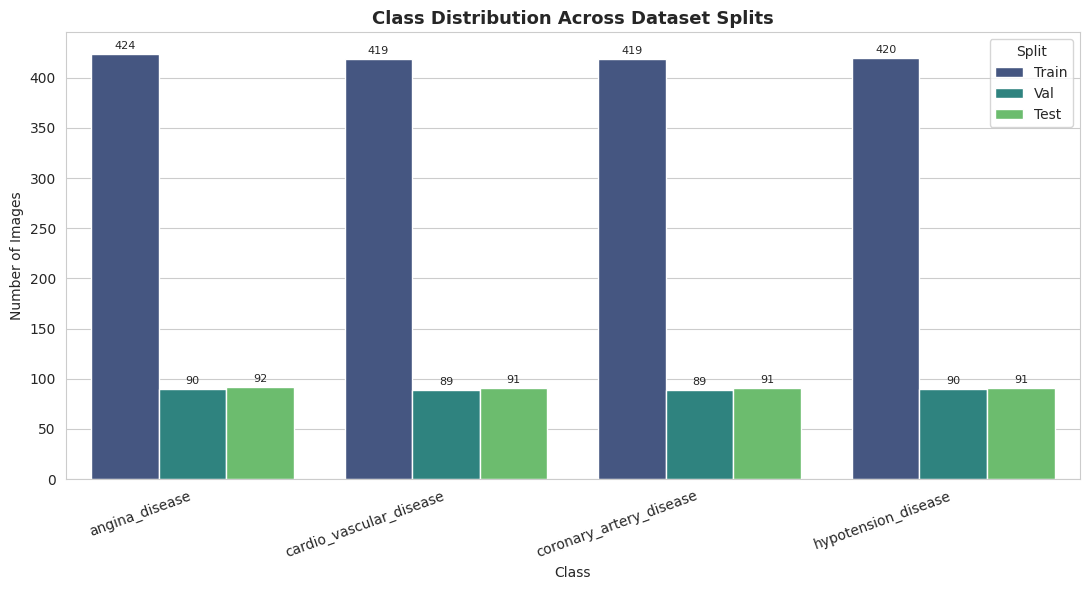

In [13]:
split_plot_df = counts_df.reset_index().melt(id_vars='index', var_name='Split', value_name='Count')
split_plot_df.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=split_plot_df, x='Class', y='Count', hue='Split', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.title('Class Distribution Across Dataset Splits', fontsize=13, fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Number of Images')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

### Overall class proportions

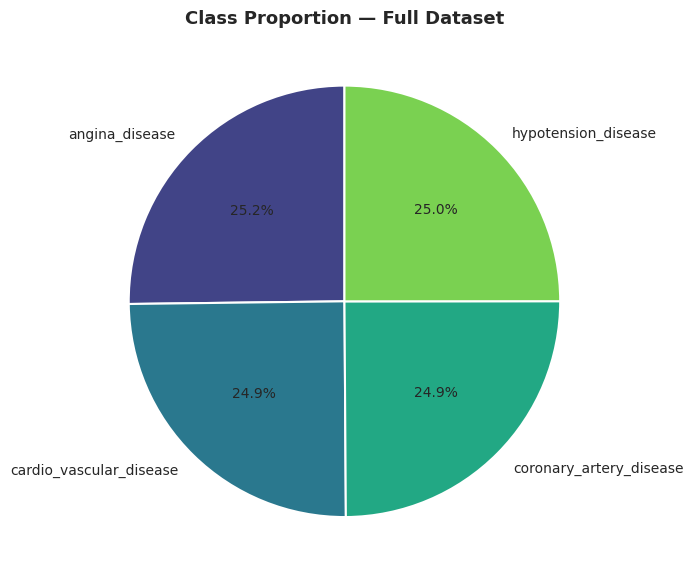

In [14]:
overall_counts = (counts_df['Train'] + counts_df['Val'] + counts_df['Test'])

plt.figure(figsize=(7, 7))
colors = sns.color_palette('viridis', num_classes)
plt.pie(
    overall_counts.values, labels=overall_counts.index, autopct='%1.1f%%',
    startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Class Proportion — Full Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Sample images per class

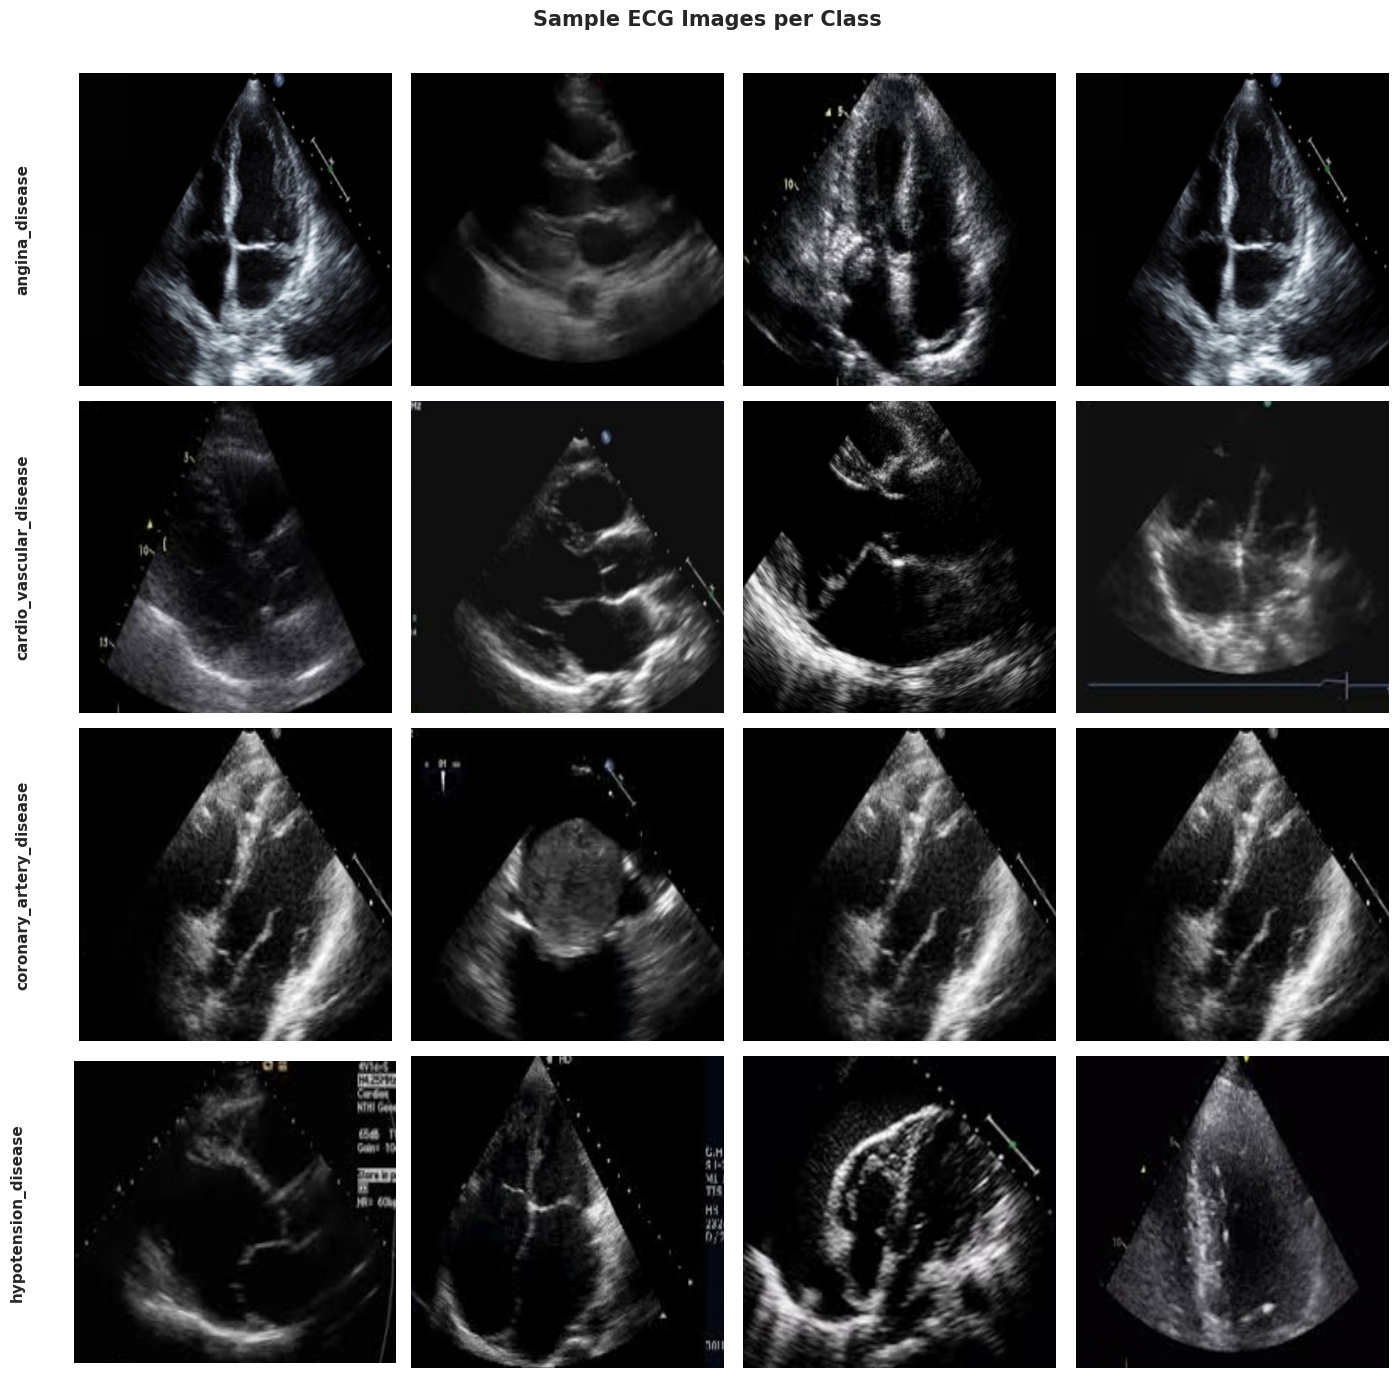

In [15]:
fig, axes = plt.subplots(num_classes, 4, figsize=(14, 3.4 * num_classes))
fig.suptitle('Sample ECG Images per Class', fontsize=15, fontweight='bold', y=1.01)

for row, cname in enumerate(class_names):
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    sample_files = random.sample(files_in_class, min(4, len(files_in_class)))

    for col in range(4):
        ax = axes[row, col]
        if col < len(sample_files):
            img = cv2.cvtColor(cv2.imread(os.path.join(class_dir, sample_files[col])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.axis('off')
    axes[row, 0].text(-0.15, 0.5, cname, transform=axes[row, 0].transAxes,
                       fontsize=11, fontweight='bold', va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()

### Pixel intensity distribution by class

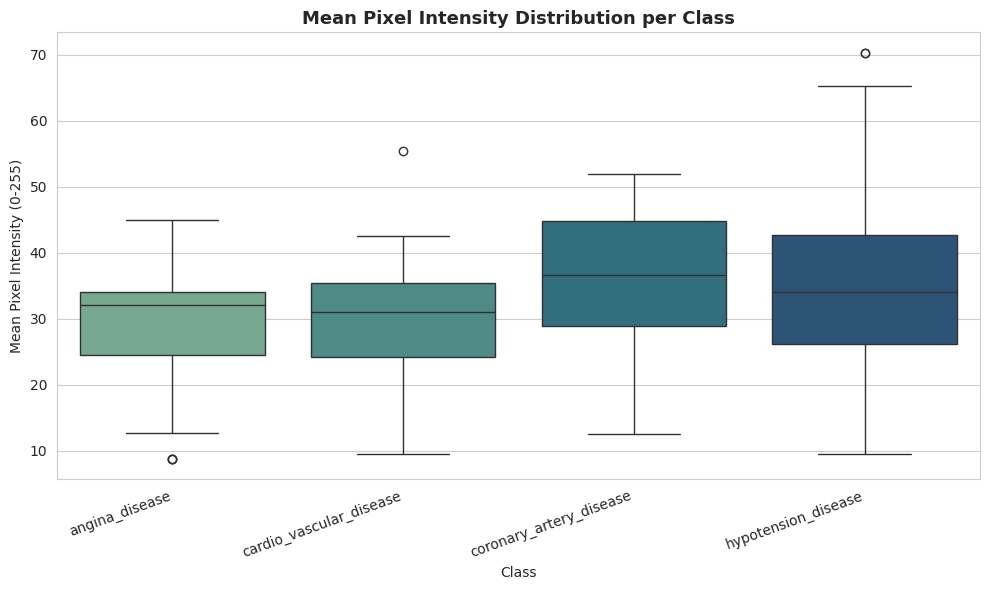

In [16]:
intensity_records = []
for cname in class_names:
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    for fname in random.sample(files_in_class, min(60, len(files_in_class))):
        img = cv2.imread(os.path.join(class_dir, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            intensity_records.append({'class': cname, 'mean_intensity': img.mean()})

intensity_df = pd.DataFrame(intensity_records)

plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x='class', y='mean_intensity', hue='class', palette='crest', legend=False)
plt.title('Mean Pixel Intensity Distribution per Class', fontsize=13, fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Mean Pixel Intensity (0-255)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Image dimension & aspect ratio distribution

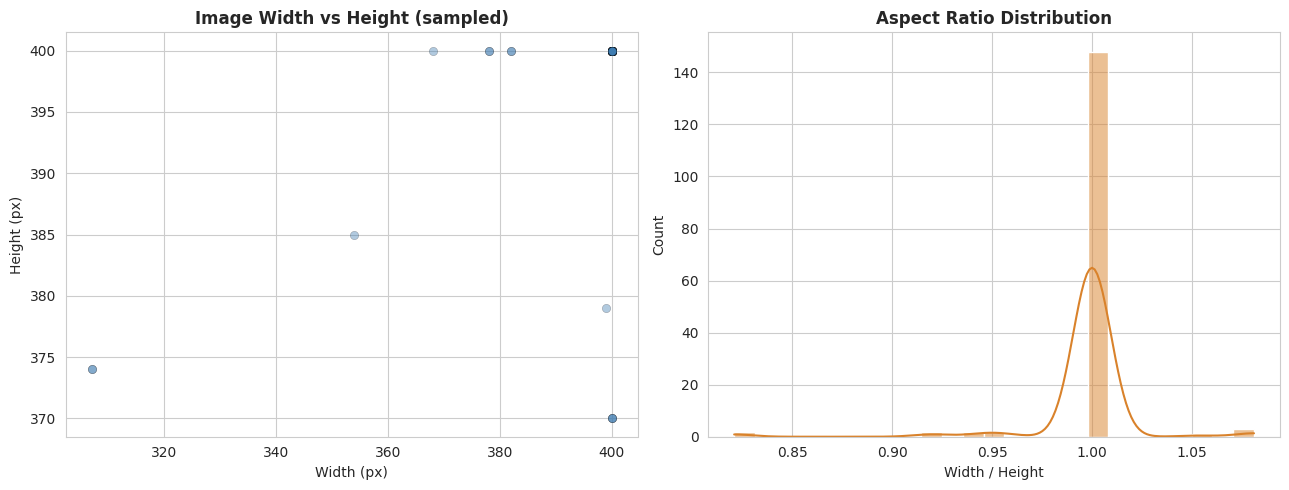

In [17]:
dim_records = []
for cname in class_names:
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    for fname in random.sample(files_in_class, min(40, len(files_in_class))):
        img = cv2.imread(os.path.join(class_dir, fname))
        if img is not None:
            h, w = img.shape[:2]
            dim_records.append({'class': cname, 'width': w, 'height': h, 'aspect_ratio': w / h})

dims_df = pd.DataFrame(dim_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(dims_df['width'], dims_df['height'], alpha=0.4, c='#3E7CB1', edgecolor='k', linewidth=0.3)
axes[0].set_title('Image Width vs Height (sampled)', fontweight='bold')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')

sns.histplot(dims_df['aspect_ratio'], bins=25, kde=True, ax=axes[1], color='#D9822B')
axes[1].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[1].set_xlabel('Width / Height')

plt.tight_layout()
plt.show()

### Edge detection (QRS pattern view)

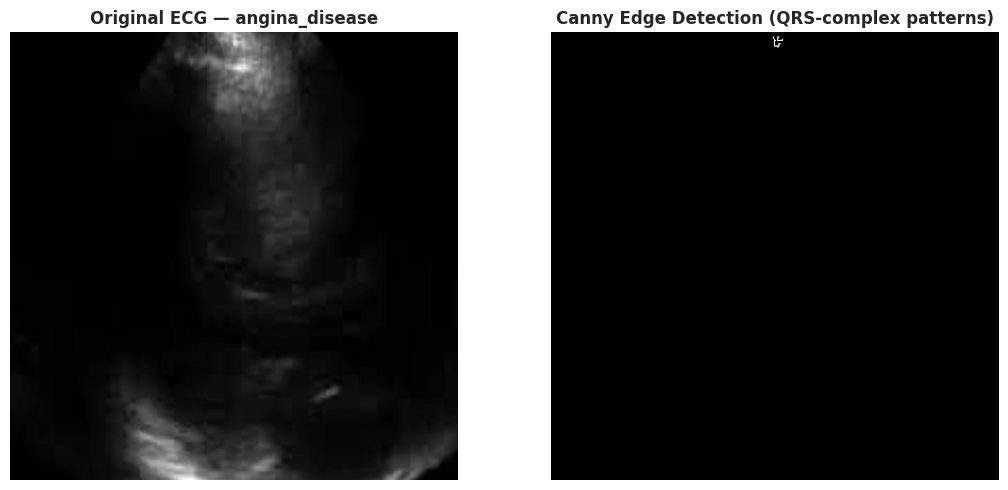

In [18]:
sample_class_dir = os.path.join(train_path, class_names[0])
sample_file = os.listdir(sample_class_dir)[0]
sample_gray = cv2.imread(os.path.join(sample_class_dir, sample_file), cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(sample_gray, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title(f'Original ECG — {class_names[0]}', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detection (QRS-complex patterns)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## **Data Generators & Class Weights**

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=True, seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 290 images belonging to 4 classes.
Found 63 images belonging to 4 classes.
Found 51 images belonging to 4 classes.
Class indices: {'angina_disease': 0, 'cardio_vascular_disease': 1, 'coronary_artery_disease': 2, 'hypotension_disease': 3}


In [20]:
counts = Counter(train_generator.classes)
counts_arr = np.array(list(counts.values()))
imbalance_ratio = counts_arr.max() / counts_arr.min()
print(f"Imbalance Ratio (max/min class count): {imbalance_ratio:.2f}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Imbalance Ratio (max/min class count): 2.43
Class Weights: {0: np.float64(0.6092436974789915), 1: np.float64(1.2719298245614035), 2: np.float64(1.1153846153846154), 3: np.float64(1.4795918367346939)}


## *Reusable Training / Evaluation Utilities**

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

model_metrics = []   # collects [name, accuracy, precision, recall, f1] for every model
trained_models = {}  # name -> keras model, used later for multi-model comparison

In [22]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'], marker='o', label='Train')
    axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], marker='o', label='Train')
    axes[1].plot(history.history['val_loss'], marker='o', label='Validation')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, cbar=True)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

In [24]:
def plot_roc_curves(y_true, y_pred_prob, model_name):
    """One-vs-rest ROC curve per class, plus micro-average."""
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

    plt.figure(figsize=(6.5, 5.5))
    for i, (cname, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{cname} (AUC={auc(fpr, tpr):.2f})')

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    plt.plot(fpr_micro, tpr_micro, color='black', lw=2, linestyle='--',
              label=f'Micro-avg (AUC={auc(fpr_micro, tpr_micro):.2f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

In [25]:
def full_evaluation(model, model_name, history=None):
    """
    Runs inference on the test set, prints the metrics table + classification
    report, and plots training curves (if provided), confusion matrix and ROC
    curves for a single model's training run.
    """
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"{'=' * 62}\n{model_name} — Test Set Performance\n{'=' * 62}")
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    if history is not None:
        plot_training_history(history, model_name)
    plot_confusion_matrix(y_true, y_pred, model_name)
    plot_roc_curves(y_true, y_pred_prob, model_name)

    model_metrics.append([model_name, acc, prec, rec, f1])
    trained_models[model_name] = model
    return y_true, y_pred, y_pred_prob

In [26]:
def build_transfer_model(base_model_class, num_classes, input_shape=(224, 224, 3),
                          unfreeze_last_n=40):
    """Generic transfer-learning head: partially fine-tuned backbone + GAP + Dense."""
    base = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_last_n]:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs)
    return model, base

## **Model Training (3 models)**

### **ResNet50 (transfer learning, partially fine-tuned)**

In [27]:
resnet_model, resnet_base = build_transfer_model(ResNet50, num_classes, unfreeze_last_n=40)
resnet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 17,014,788 (64.91 MB)

 Non-trainable params: 7,757,440 (29.59 MB)

In [28]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 131s 11s/step - accuracy: 0.4069 - loss: 1.8605 - val_accuracy: 0.3175 - val_loss: 1.7480 - learning_rate: 1.0000e-04
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 10s/step - accuracy: 0.4655 - loss: 1.5404 - val_accuracy: 0.2381 - val_loss: 1.7462 - learning_rate: 1.0000e-04
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 10s/step - accuracy: 0.5276 - loss: 1.2698 - val_accuracy: 0.2540 - val_loss: 1.7110 - learning_rate: 1.0000e-04
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 10s/step - accuracy: 0.5241 - loss: 1.2719 - val_accuracy: 0.1429 - val_loss: 1.6619 - learning_rate: 1.0000e-04
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 101s 10s/step - accuracy: 0.5448 - loss: 1.2475 - val_accuracy: 0.1429 - val_loss: 1.5969 - learning_rate: 1.0000e-04
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 112s 11s/step - accuracy: 0.5931 - loss: 1.2167 - val_accuracy: 0.1270 - val_loss: 1.5428 - learning_rate: 1.0000e-04
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 108s 12s/step - accuracy: 

ResNet50 — Test Set Performance
Accuracy : 0.2745
Precision: 0.5691
Recall   : 0.2745
F1-score : 0.2097

                         precision    recall  f1-score   support

         angina_disease       1.00      0.08      0.15        24
cardio_vascular_disease       0.38      0.71      0.50         7
coronary_artery_disease       0.00      0.00      0.00         8
    hypotension_disease       0.19      0.58      0.29        12

               accuracy                           0.27        51
              macro avg       0.39      0.35      0.24        51
           weighted avg       0.57      0.27      0.21        51



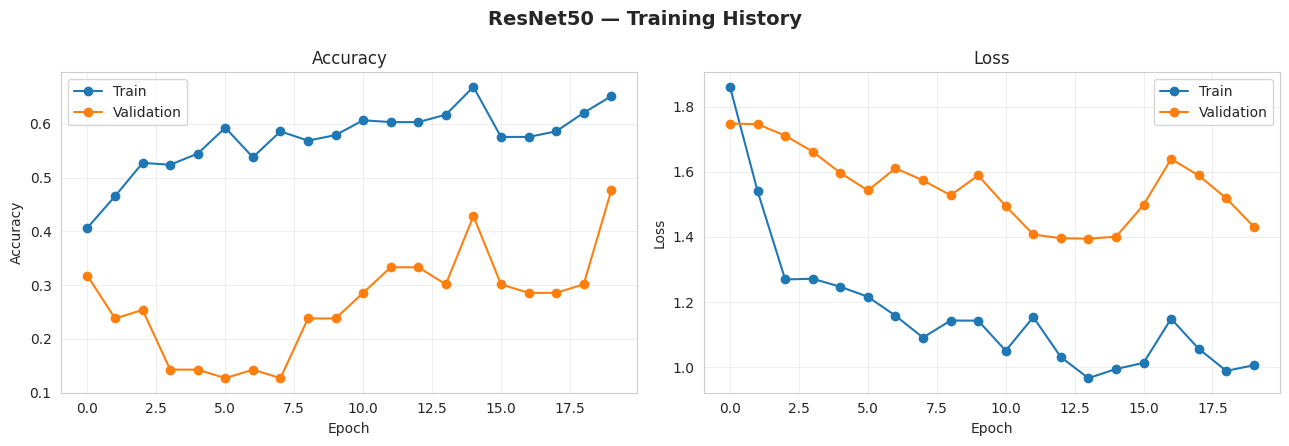

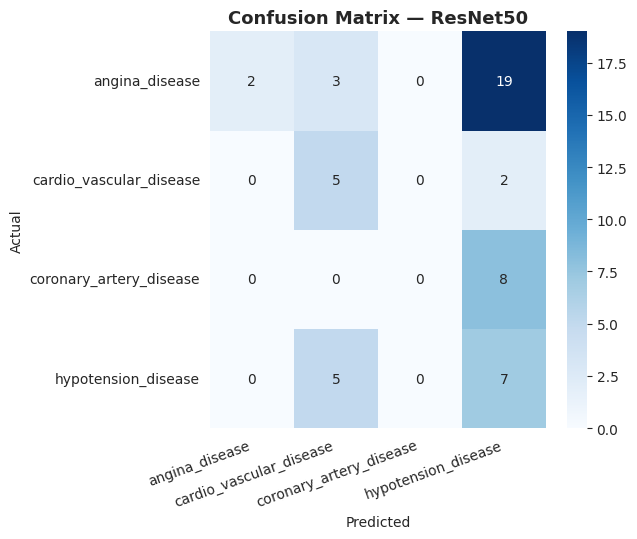

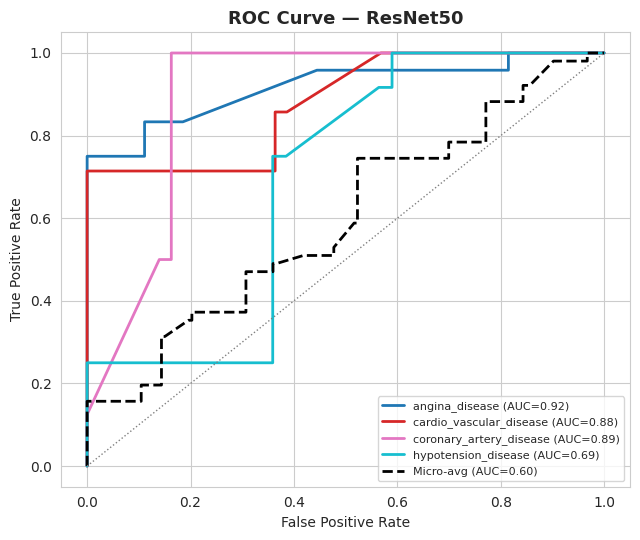

In [29]:
_, y_pred_resnet, _ = full_evaluation(resnet_model, "ResNet50", history_resnet)

### **DenseNet121 (transfer learning, partially fine-tuned)**

In [30]:
densenet_model, densenet_base = build_transfer_model(DenseNet121, num_classes, unfreeze_last_n=40)
densenet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,697,732 (29.36 MB)

 Trainable params: 1,486,404 (5.67 MB)

 Non-trainable params: 6,211,328 (23.69 MB)

In [31]:
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 96s 7s/step - accuracy: 0.3517 - loss: 1.7554 - val_accuracy: 0.2857 - val_loss: 1.3337 - learning_rate: 1.0000e-04
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.4862 - loss: 1.2281 - val_accuracy: 0.4286 - val_loss: 1.1939 - learning_rate: 1.0000e-04
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.5690 - loss: 1.0956 - val_accuracy: 0.6508 - val_loss: 1.0906 - learning_rate: 1.0000e-04
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.6207 - loss: 0.9853 - val_accuracy: 0.6667 - val_loss: 1.0077 - learning_rate: 1.0000e-04
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.6448 - loss: 0.8512 - val_accuracy: 0.6984 - val_loss: 0.9263 - learning_rate: 1.0000e-04
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.6276 - loss: 0.9433 - val_accuracy: 0.6984 - val_loss: 0.8577 - learning_rate: 1.0000e-04
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.7000 - loss:

DenseNet121 — Test Set Performance
Accuracy : 0.8627
Precision: 0.9268
Recall   : 0.8627
F1-score : 0.8766

                         precision    recall  f1-score   support

         angina_disease       1.00      0.88      0.93        24
cardio_vascular_disease       1.00      0.71      0.83         7
coronary_artery_disease       0.53      1.00      0.70         8
    hypotension_disease       1.00      0.83      0.91        12

               accuracy                           0.86        51
              macro avg       0.88      0.86      0.84        51
           weighted avg       0.93      0.86      0.88        51



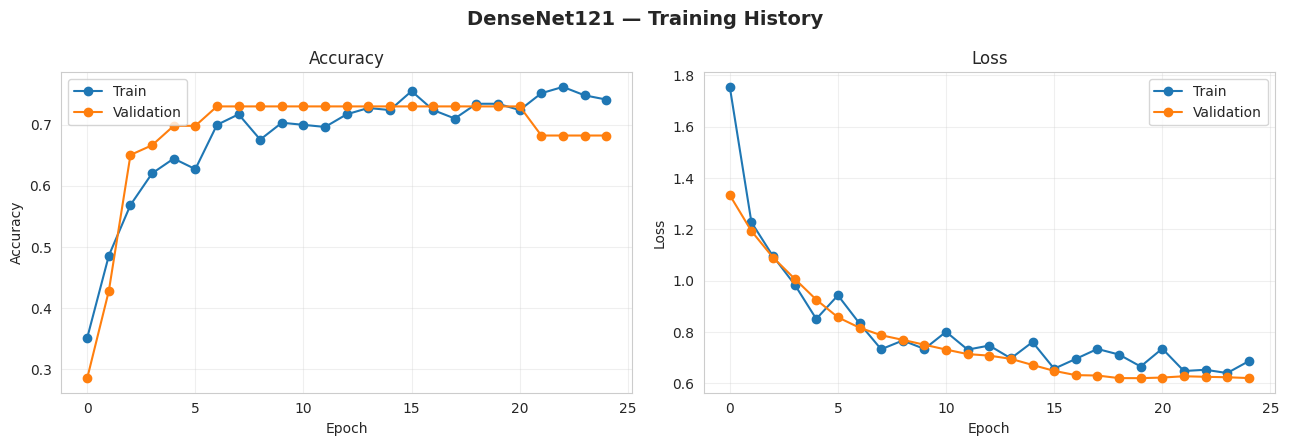

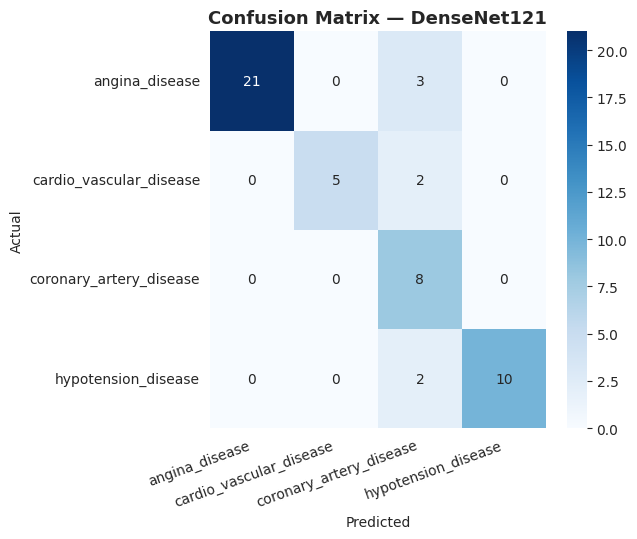

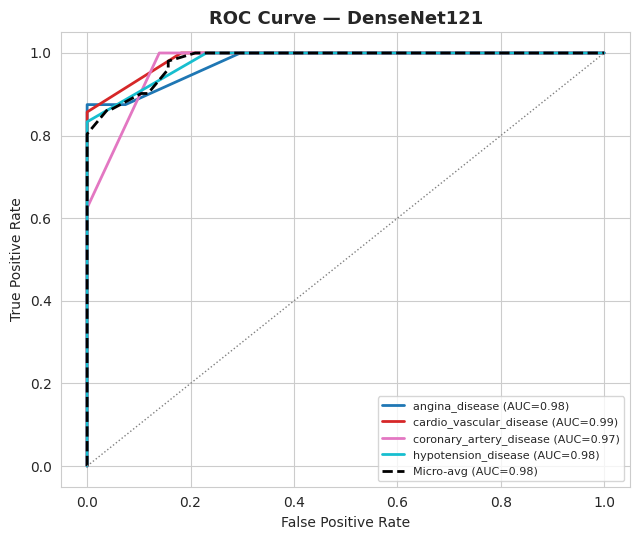

In [32]:
_, y_pred_densenet, _ = full_evaluation(densenet_model, "DenseNet121", history_densenet)

### **Hybrid CNN-Transformer (novel architecture)**

In [33]:
class PositionalEmbedding(layers.Layer):
    """Learnable positional embedding added to a sequence of patch tokens."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embed = self.add_weight(
            name="pos_embed", shape=(1, num_patches, embed_dim),
            initializer="random_normal", trainable=True
        )

    def call(self, x):
        return x + self.pos_embed


def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout=0.1):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(ff_dim, activation='gelu')(x)
    ffn_output = layers.Dense(x.shape[-1])(ffn_output)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)
    return x


def build_hybrid_cnn_transformer(input_shape=(224, 224, 3), num_classes=num_classes,
                                  embed_dim=128, num_transformer_blocks=4,
                                  num_heads=4, ff_dim=256, dropout=0.1, unfreeze_last_n=40):
    inputs = layers.Input(shape=input_shape)

    # --- CNN branch: local feature extraction ---
    cnn_backbone = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    cnn_backbone.trainable = True
    for layer in cnn_backbone.layers[:-unfreeze_last_n]:
        layer.trainable = False

    feature_map = cnn_backbone(inputs)                       # (7, 7, 1280)
    x = layers.Conv2D(embed_dim, kernel_size=1, padding='same')(feature_map)

    h, w = x.shape[1], x.shape[2]
    num_patches = h * w
    x = layers.Reshape((num_patches, embed_dim))(x)           # sequence of visual tokens
    x = PositionalEmbedding(num_patches, embed_dim)(x)

    # --- Transformer branch: global context modelling ---
    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads, embed_dim // num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='Hybrid_CNN_Transformer')
    return model, cnn_backbone

In [34]:
hybrid_model, hybrid_backbone = build_hybrid_cnn_transformer(input_shape=(*image_size, 3), num_classes=num_classes)
hybrid_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
hybrid_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Hybrid_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 128) │    163,968 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 128)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 128)   │      6,272 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 128)   │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 49, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 128)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 49, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 49, 128)   │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 49, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 49, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 49, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,024,580 (11.54 MB)

 Trainable params: 2,448,132 (9.34 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [35]:
history_hybrid = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.3310 - loss: 1.3865 - val_accuracy: 0.5397 - val_loss: 1.2660 - learning_rate: 1.0000e-04
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.5517 - loss: 1.1546 - val_accuracy: 0.5714 - val_loss: 1.1888 - learning_rate: 1.0000e-04
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6467 - loss: 0.9511
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.6724 - loss: 0.9466 - val_accuracy: 0.5873 - val_loss: 1.0518 - learning_rate: 1.0000e-04
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7172 - loss: 0.8428 - val_accuracy: 0.6349 - val_loss: 1.0128 - learning_rate: 3.0000e-05
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7241 - loss: 0.8177 - val_accuracy: 0.7302 - val_loss: 0.9884 - learning_rate: 3.0000e-05
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7617 - loss: 0.764

Hybrid CNN-Transformer — Test Set Performance
Accuracy : 0.5686
Precision: 0.3484
Recall   : 0.5686
F1-score : 0.4286

                         precision    recall  f1-score   support

         angina_disease       0.56      1.00      0.72        24
cardio_vascular_disease       0.62      0.71      0.67         7
coronary_artery_disease       0.00      0.00      0.00         8
    hypotension_disease       0.00      0.00      0.00        12

               accuracy                           0.57        51
              macro avg       0.30      0.43      0.35        51
           weighted avg       0.35      0.57      0.43        51



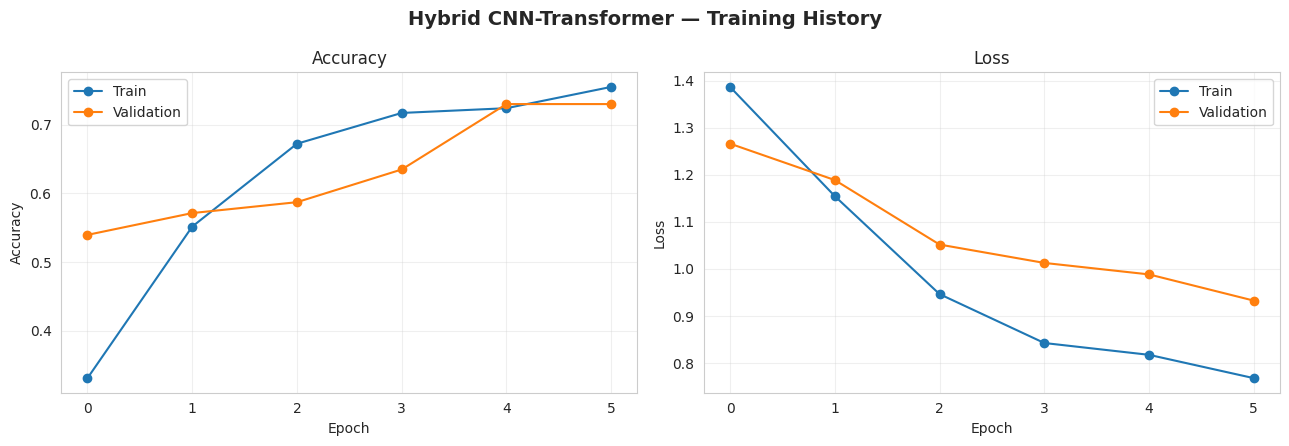

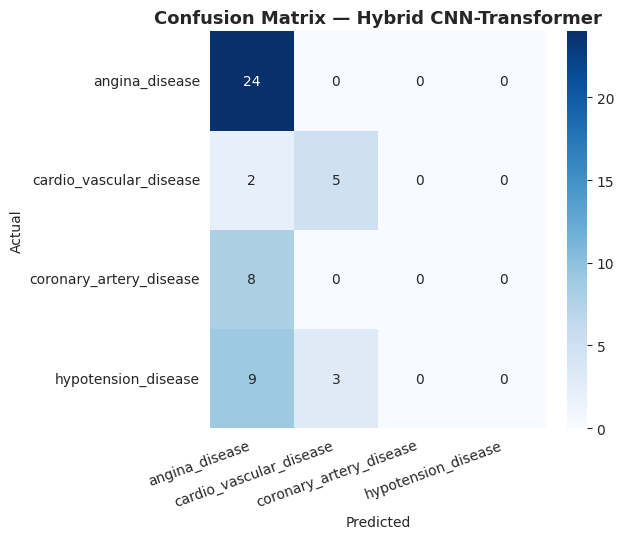

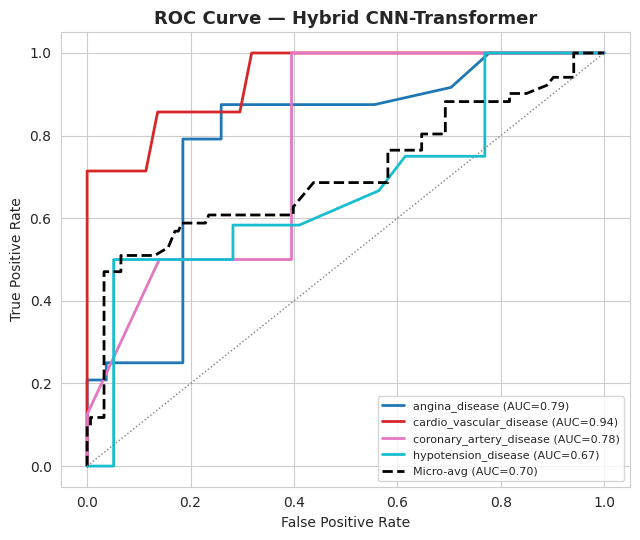

In [36]:
_, y_pred_hybrid, _ = full_evaluation(hybrid_model, "Hybrid CNN-Transformer", history_hybrid)

## **Model Comparison**

In [37]:
df_results = pd.DataFrame(model_metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df_results = df_results.sort_values(by="F1", ascending=False).reset_index(drop=True)
df_results

,Model,Accuracy,Precision,Recall,F1
0,DenseNet121,0.862745,0.926797,0.862745,0.876620
1,Hybrid CNN-Transformer,0.568627,0.348438,0.568627,0.428641
2,ResNet50,0.274510,0.569130,0.274510,0.209653


### Accuracy comparison

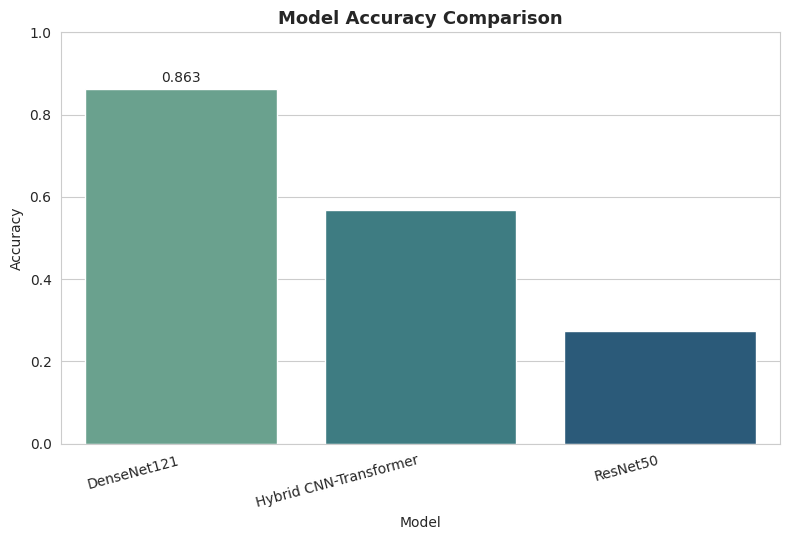

In [38]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x='Model', y='Accuracy', hue='Model', palette='crest', legend=False)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Precision comparison

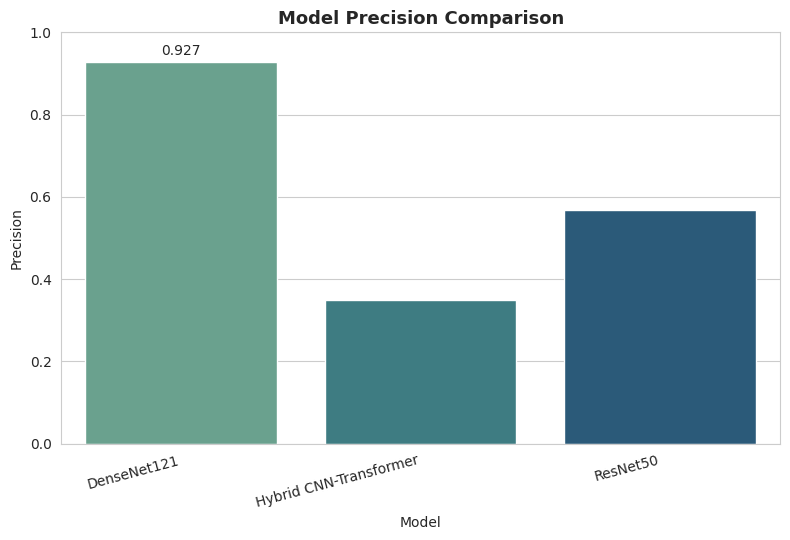

In [39]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x='Model', y='Precision', hue='Model', palette='crest', legend=False)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
plt.title('Model Precision Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Recall comparison

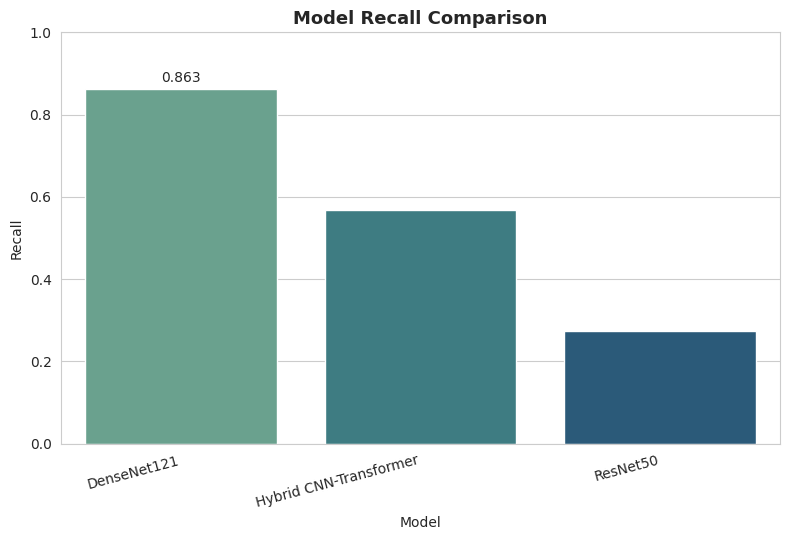

In [40]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x='Model', y='Recall', hue='Model', palette='crest', legend=False)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
plt.title('Model Recall Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### F1-score comparison

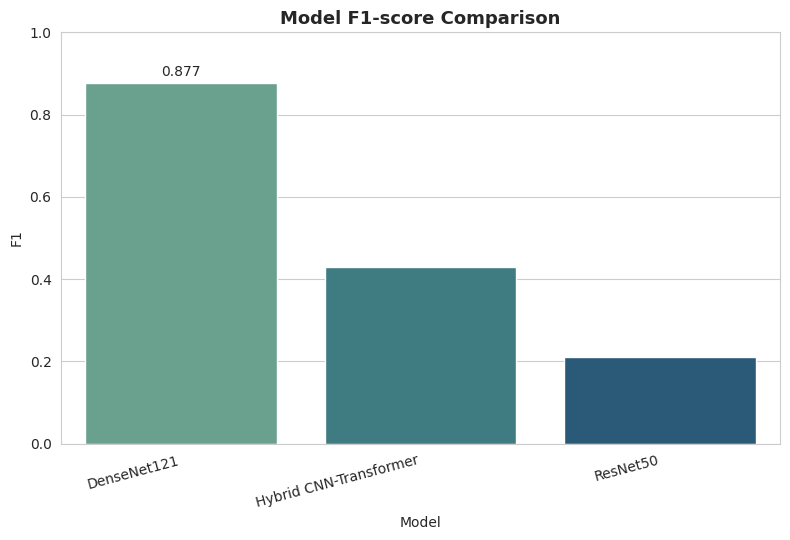

In [41]:
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=df_results, x='Model', y='F1', hue='Model', palette='crest', legend=False)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
plt.title('Model F1-score Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### All metrics — combined comparison

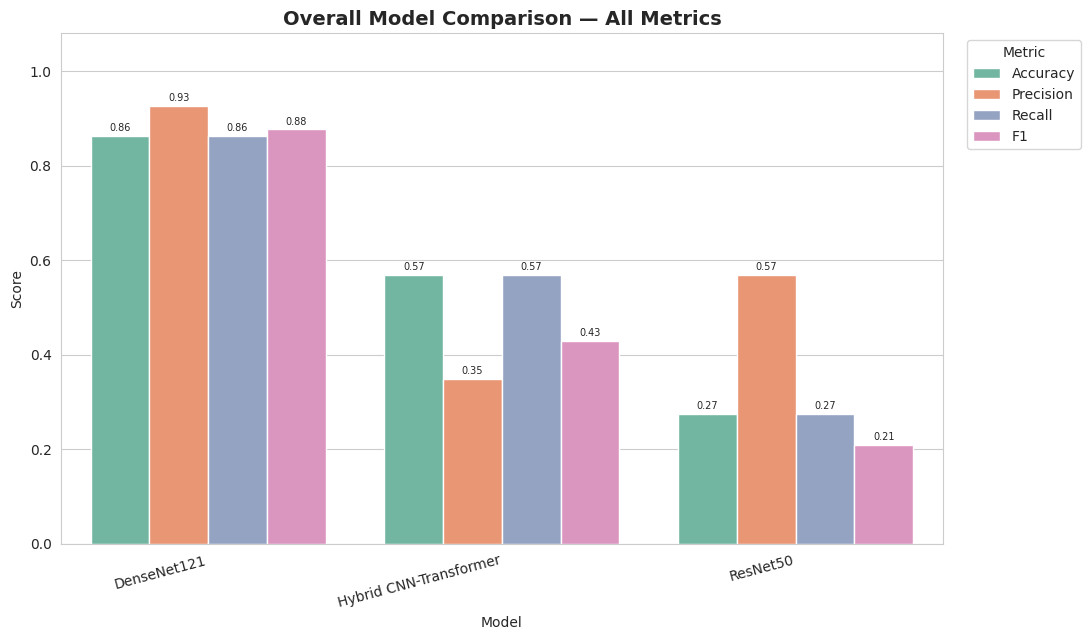

In [42]:
metrics_melt = df_results.melt(
    id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(data=metrics_melt, x='Model', y='Score', hue='Metric', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.title('Overall Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.ylim(0, 1.08)
plt.xlabel('Model'); plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Best Model (by F1-score): {best_model_name}")

Best Model (by F1-score): DenseNet121


## **Sample Predictions — 4 Images per Class, All Models**

In [44]:
def load_and_preprocess(img_path, target_size=image_size):
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    return arr

model_order = list(trained_models.keys())
n_models = len(model_order)

class_test_samples = {}
for cname in class_names:
    class_dir = os.path.join(test_path, cname)
    files_in_class = os.listdir(class_dir)
    sample_files = random.sample(files_in_class, min(4, len(files_in_class)))
    class_test_samples[cname] = [
        {'path': os.path.join(class_dir, f), 'true_label': cname,
         'array': load_and_preprocess(os.path.join(class_dir, f))}
        for f in sample_files
    ]

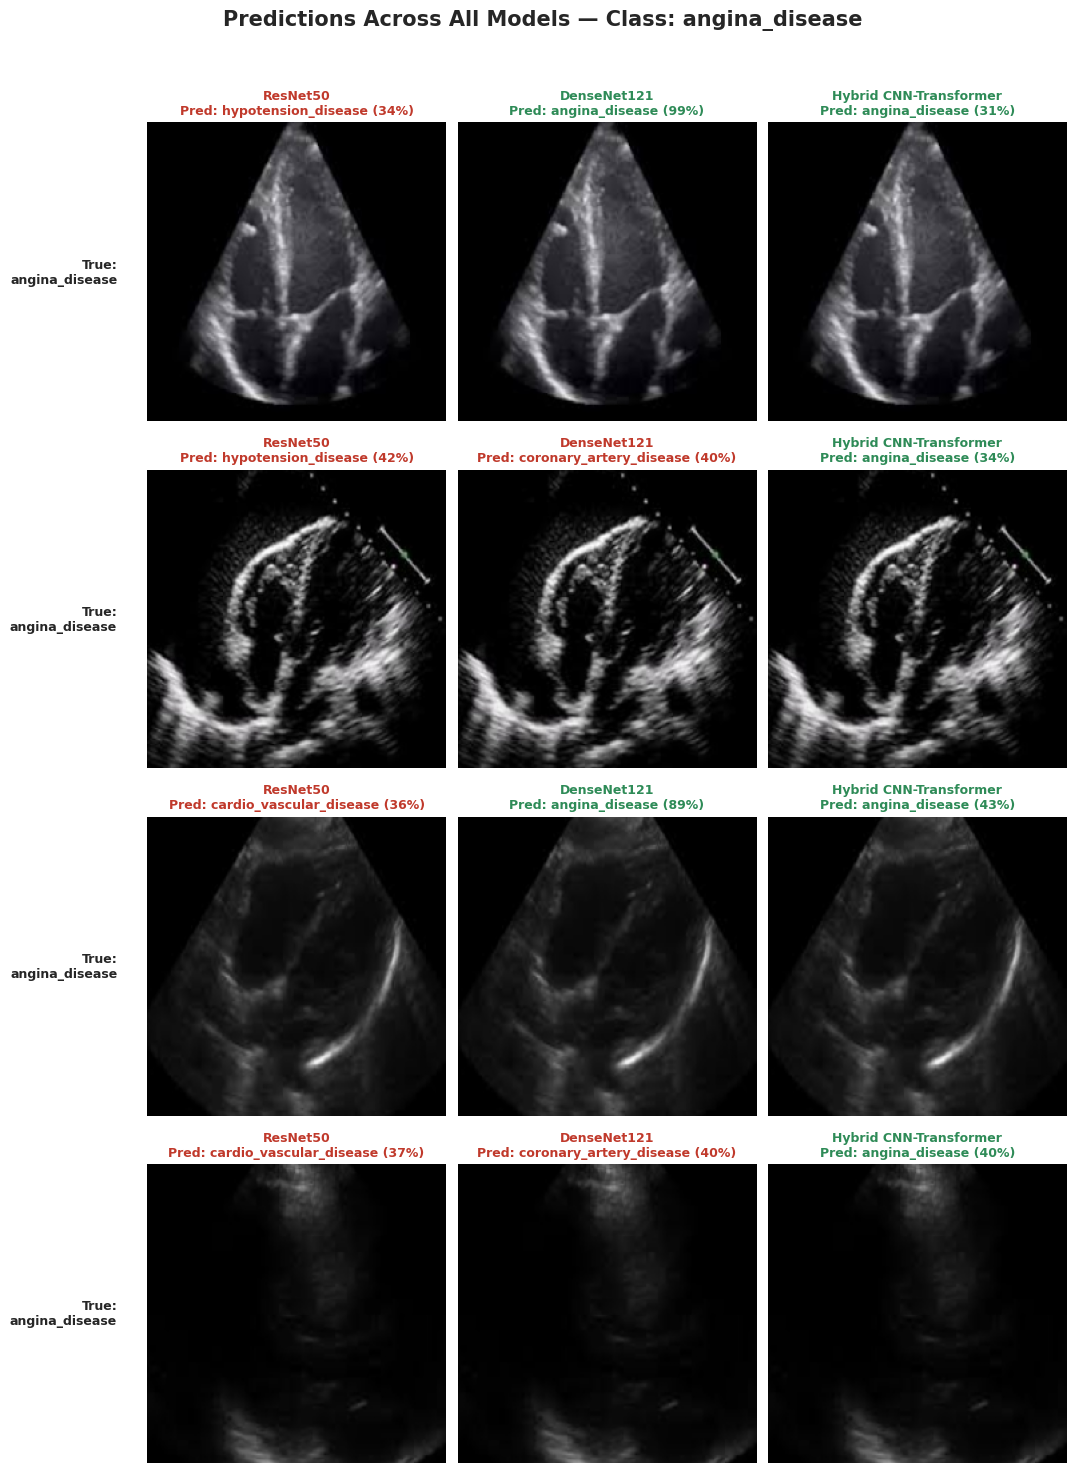

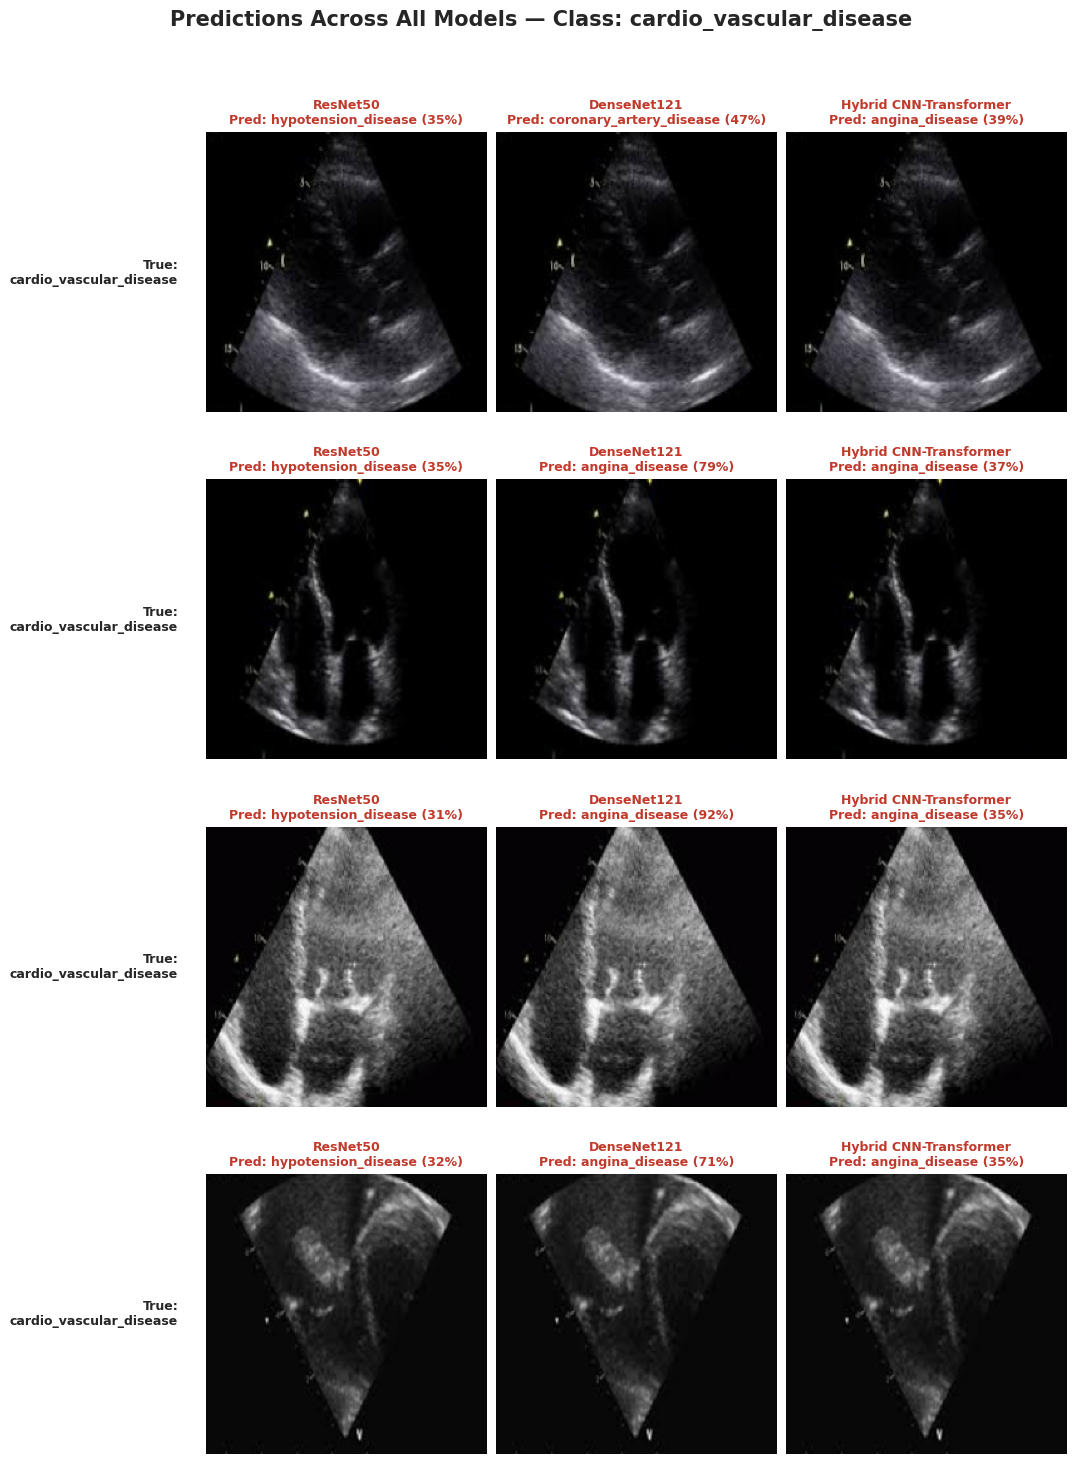

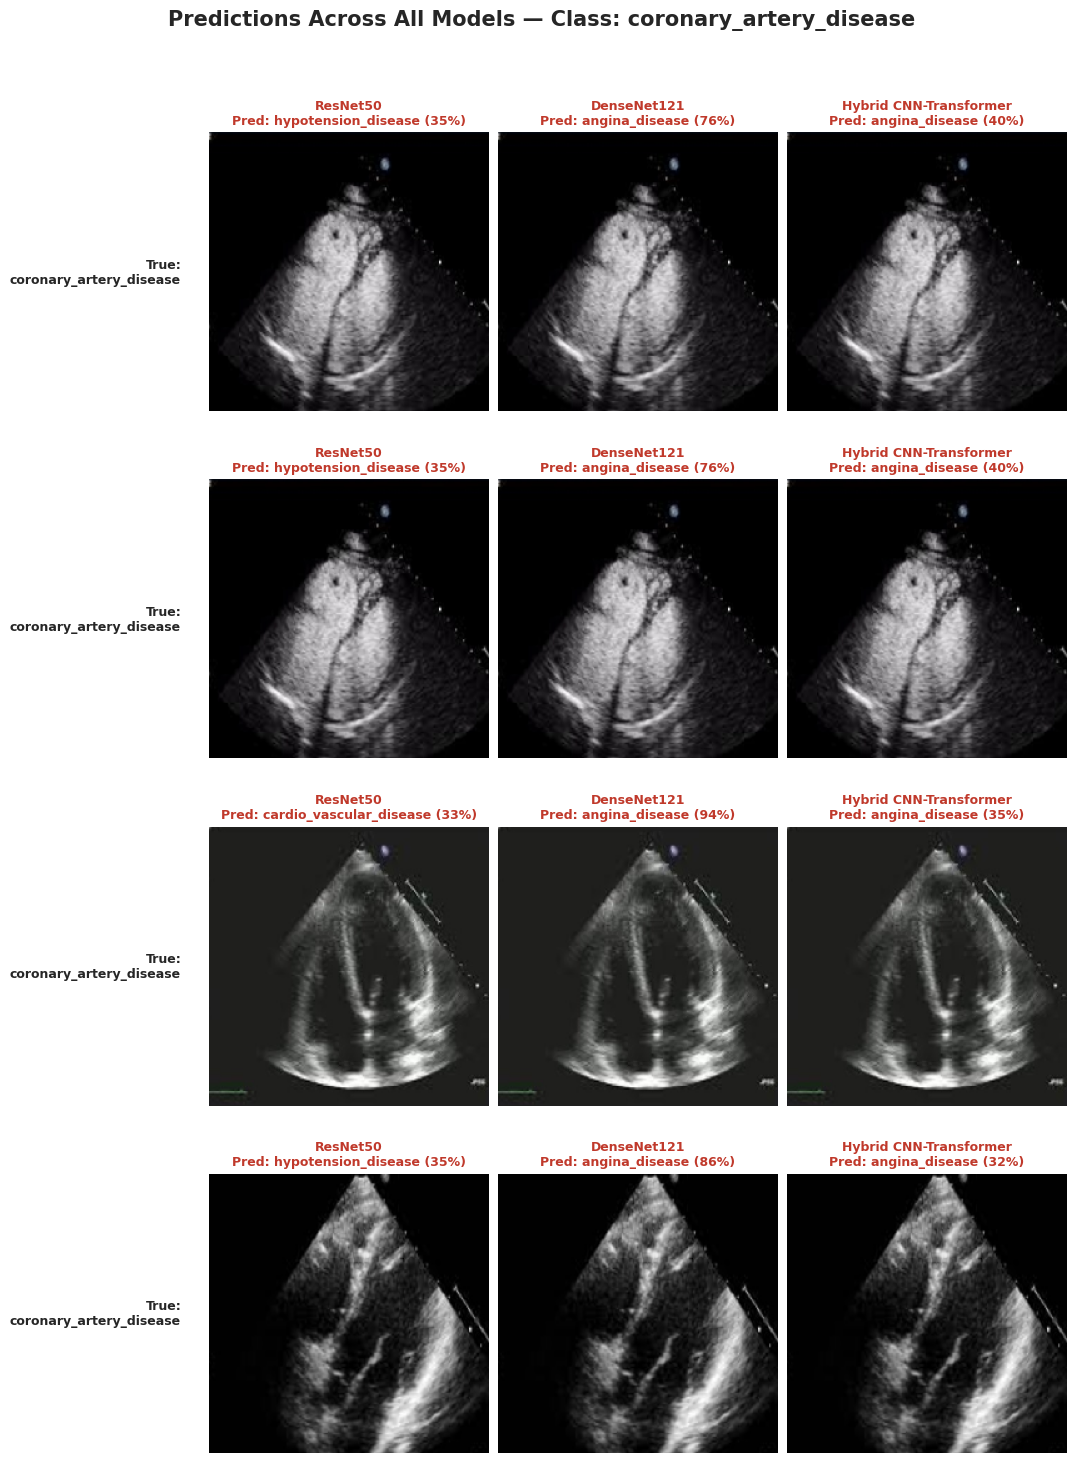

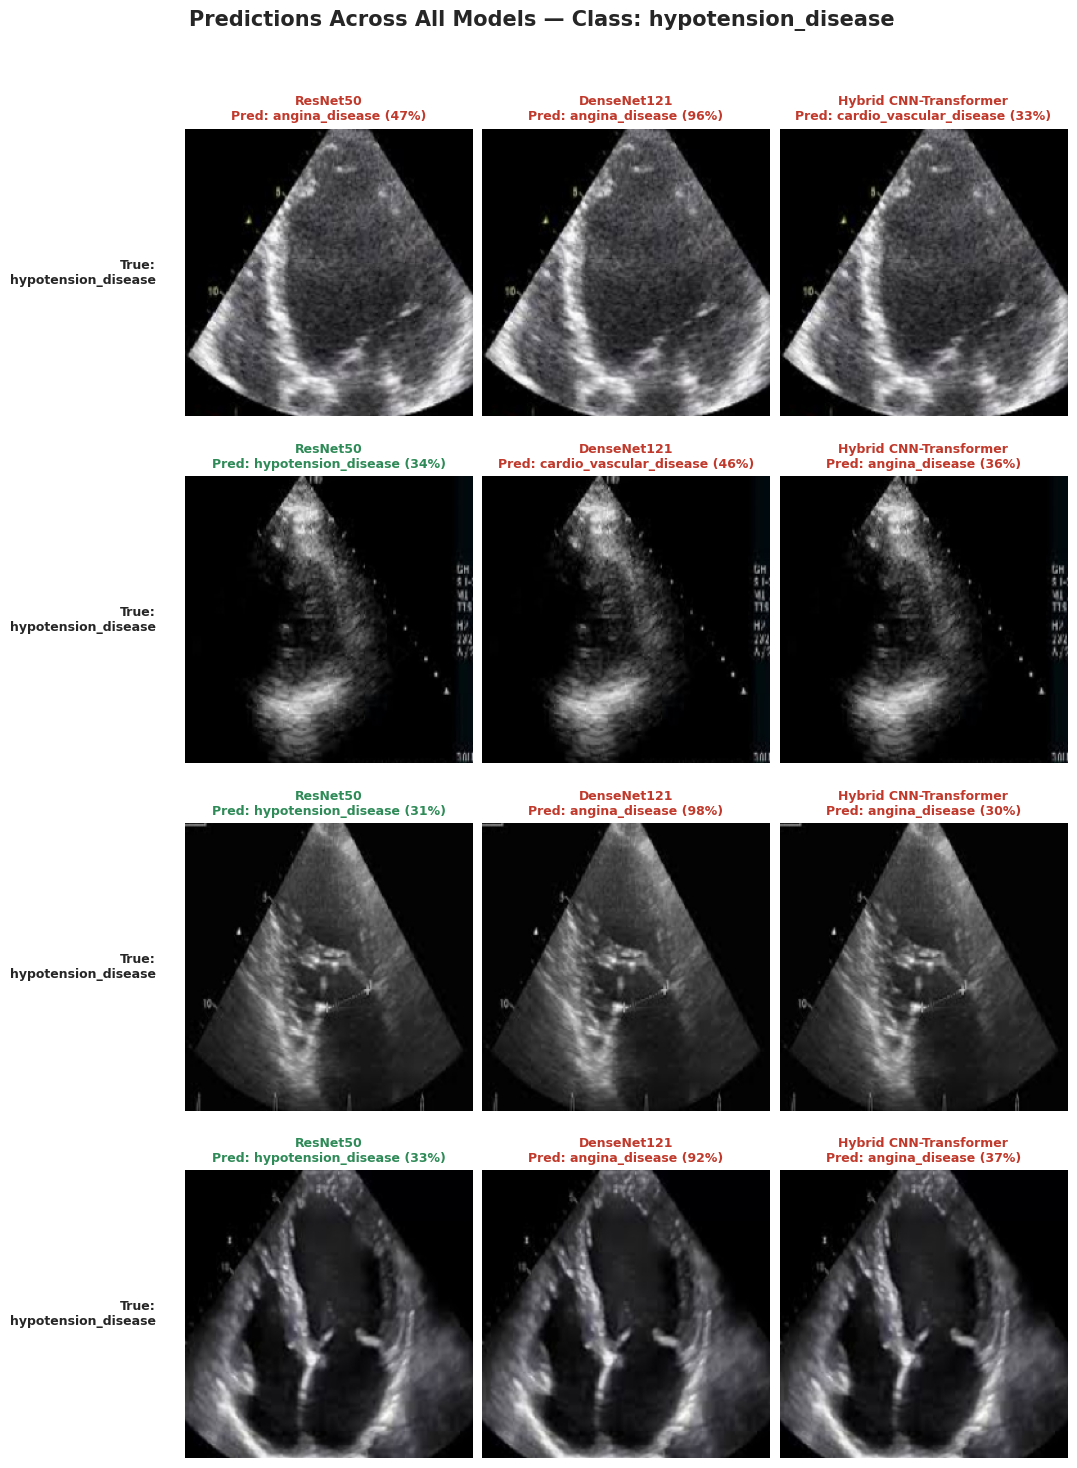

In [45]:
for cname in class_names:
    samples = class_test_samples[cname]
    n_rows = len(samples)

    fig, axes = plt.subplots(n_rows, n_models, figsize=(3.6 * n_models, 3.6 * n_rows))
    fig.suptitle(f'Predictions Across All Models — Class: {cname}', fontsize=15, fontweight='bold', y=1.02)

    for row, sample in enumerate(samples):
        img_batch = np.expand_dims(sample['array'], axis=0)
        for col, model_name in enumerate(model_order):
            model = trained_models[model_name]
            probs = model.predict(img_batch, verbose=0)[0]
            pred_idx = np.argmax(probs)
            pred_label = class_names[pred_idx]
            confidence = probs[pred_idx]
            correct = pred_label == sample['true_label']

            ax = axes[row, col] if n_rows > 1 else axes[col]
            ax.imshow(sample['array'])
            ax.axis('off')
            color = '#2E8B57' if correct else '#C0392B'
            ax.set_title(f"{model_name}\nPred: {pred_label} ({confidence:.0%})",
                          fontsize=9, color=color, fontweight='bold')
            if col == 0:
                ax.text(-0.1, 0.5, f"True:\n{sample['true_label']}", transform=ax.transAxes,
                         fontsize=9, fontweight='bold', va='center', ha='right', rotation=0)

    plt.tight_layout()
    plt.show()